# LeetCode #367: Valid Perfect Square

https://leetcode.com/problems/valid-perfect-square/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(\sqrt{n})$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Iterate $i = 1, 2, \ldots$ and check if $i^2 == \text{num}$. Stops at $\sqrt{\text{num}}$, so $O(\sqrt{n})$. For $\text{num} = 2^{31} - 1$, that's ~46,341 iterations.

### Optimal: Binary Search ★
Binary search over $[1, \text{num}]$ for an integer $m$ such that $m^2 == \text{num}$. At each step, compute `mid*mid` (using `long` to avoid overflow): if equal, return true; if less, search right; if greater, search left. Terminates in $O(\log n)$ steps (~31 for $n = 2^{31}$).

**Why this is better than Brute Force:** $O(\log n)$ vs $O(\sqrt{n})$ — about 31 steps vs 46,341 for the maximum input.

**Constraints:**
* 1 <= num <= 2^31 - 1

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsPerfectSquare(int num) {
        long lo = 1, hi = num;
        while (lo <= hi) {
            long mid = lo + (hi - lo) / 2;
            long sq = mid * mid;
            if (sq == num) return true;
            // mid^2 too small — perfect square must be larger
            if (sq < num) lo = mid + 1;
            else hi = mid - 1;
        }
        return false;
    }
}

### Python

In [ ]:
class Solution:
    def isPerfectSquare(self, num: int) -> bool:
        lo, hi = 1, num
        while lo <= hi:
            mid = lo + (hi - lo) // 2
            sq = mid * mid
            if sq == num:
                return True
            # mid^2 too small — perfect square must be larger
            if sq < num:
                lo = mid + 1
            else:
                hi = mid - 1
        return False

### Go

In [ ]:
func isPerfectSquare(num int) bool {
    lo, hi := 1, num
    for lo <= hi {
        mid := lo + (hi-lo)/2
        sq := mid * mid
        if sq == num {
            return true
        }
        // mid^2 too small — perfect square must be larger
        if sq < num {
            lo = mid + 1
        } else {
            hi = mid - 1
        }
    }
    return false
}

### Rust

In [ ]:
impl Solution {
    pub fn is_perfect_square(num: i32) -> bool {
        let (mut lo, mut hi) = (1i64, num as i64);
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            let sq = mid * mid;
            if sq == num as i64 { return true; }
            // mid^2 too small — perfect square must be larger
            if sq < num as i64 { lo = mid + 1; } else { hi = mid - 1; }
        }
        false
    }
}

## Example Scenarios

**1. Common Case**
**Input:** num = 16
lo=1, hi=16 → mid=8, 64>16 → hi=7. mid=4, 16==16 → return true. Two steps to the exact midpoint.

**2. Slightly Complex**
**Input:** num = 14
lo=1, hi=14 → mid=7, 49>14 → hi=6. mid=3, 9<14 → lo=4. mid=5, 25>14 → hi=4. mid=4, 16>14 → hi=3. lo>hi → return false. 14 is not a perfect square ($3^2=9$, $4^2=16$).

**3. Edge Case: Time Factor**
**Input:** num = 2^31 − 1 = 2147483647 (not a perfect square; $\sqrt{2^{31}-1} \approx 46340.95$)
Binary search runs $\lfloor \log_2(2^{31}-1) \rfloor = 30$ iterations. Without `long` for `mid*mid`, $46341^2 = 2147486281$ overflows 32-bit int.

**4. Edge Case: Space Factor**
**Input:** num = 1
lo=1, hi=1 → mid=1, sq=1 == 1 → return true. Minimum input. Loop runs once, $O(1)$ space. $1 = 1^2$ is a perfect square.

**5. Almost-Impossible but Plausible**
**Input:** num = 2147395600 = 46340^2 (largest perfect square ≤ 2^31−1)
mid eventually equals 46340; sq = 46340^2 = 2147395600 == num → return true. Requires full binary search depth (~30 steps). Without int64, $46341^2$ overflows during an intermediate check.

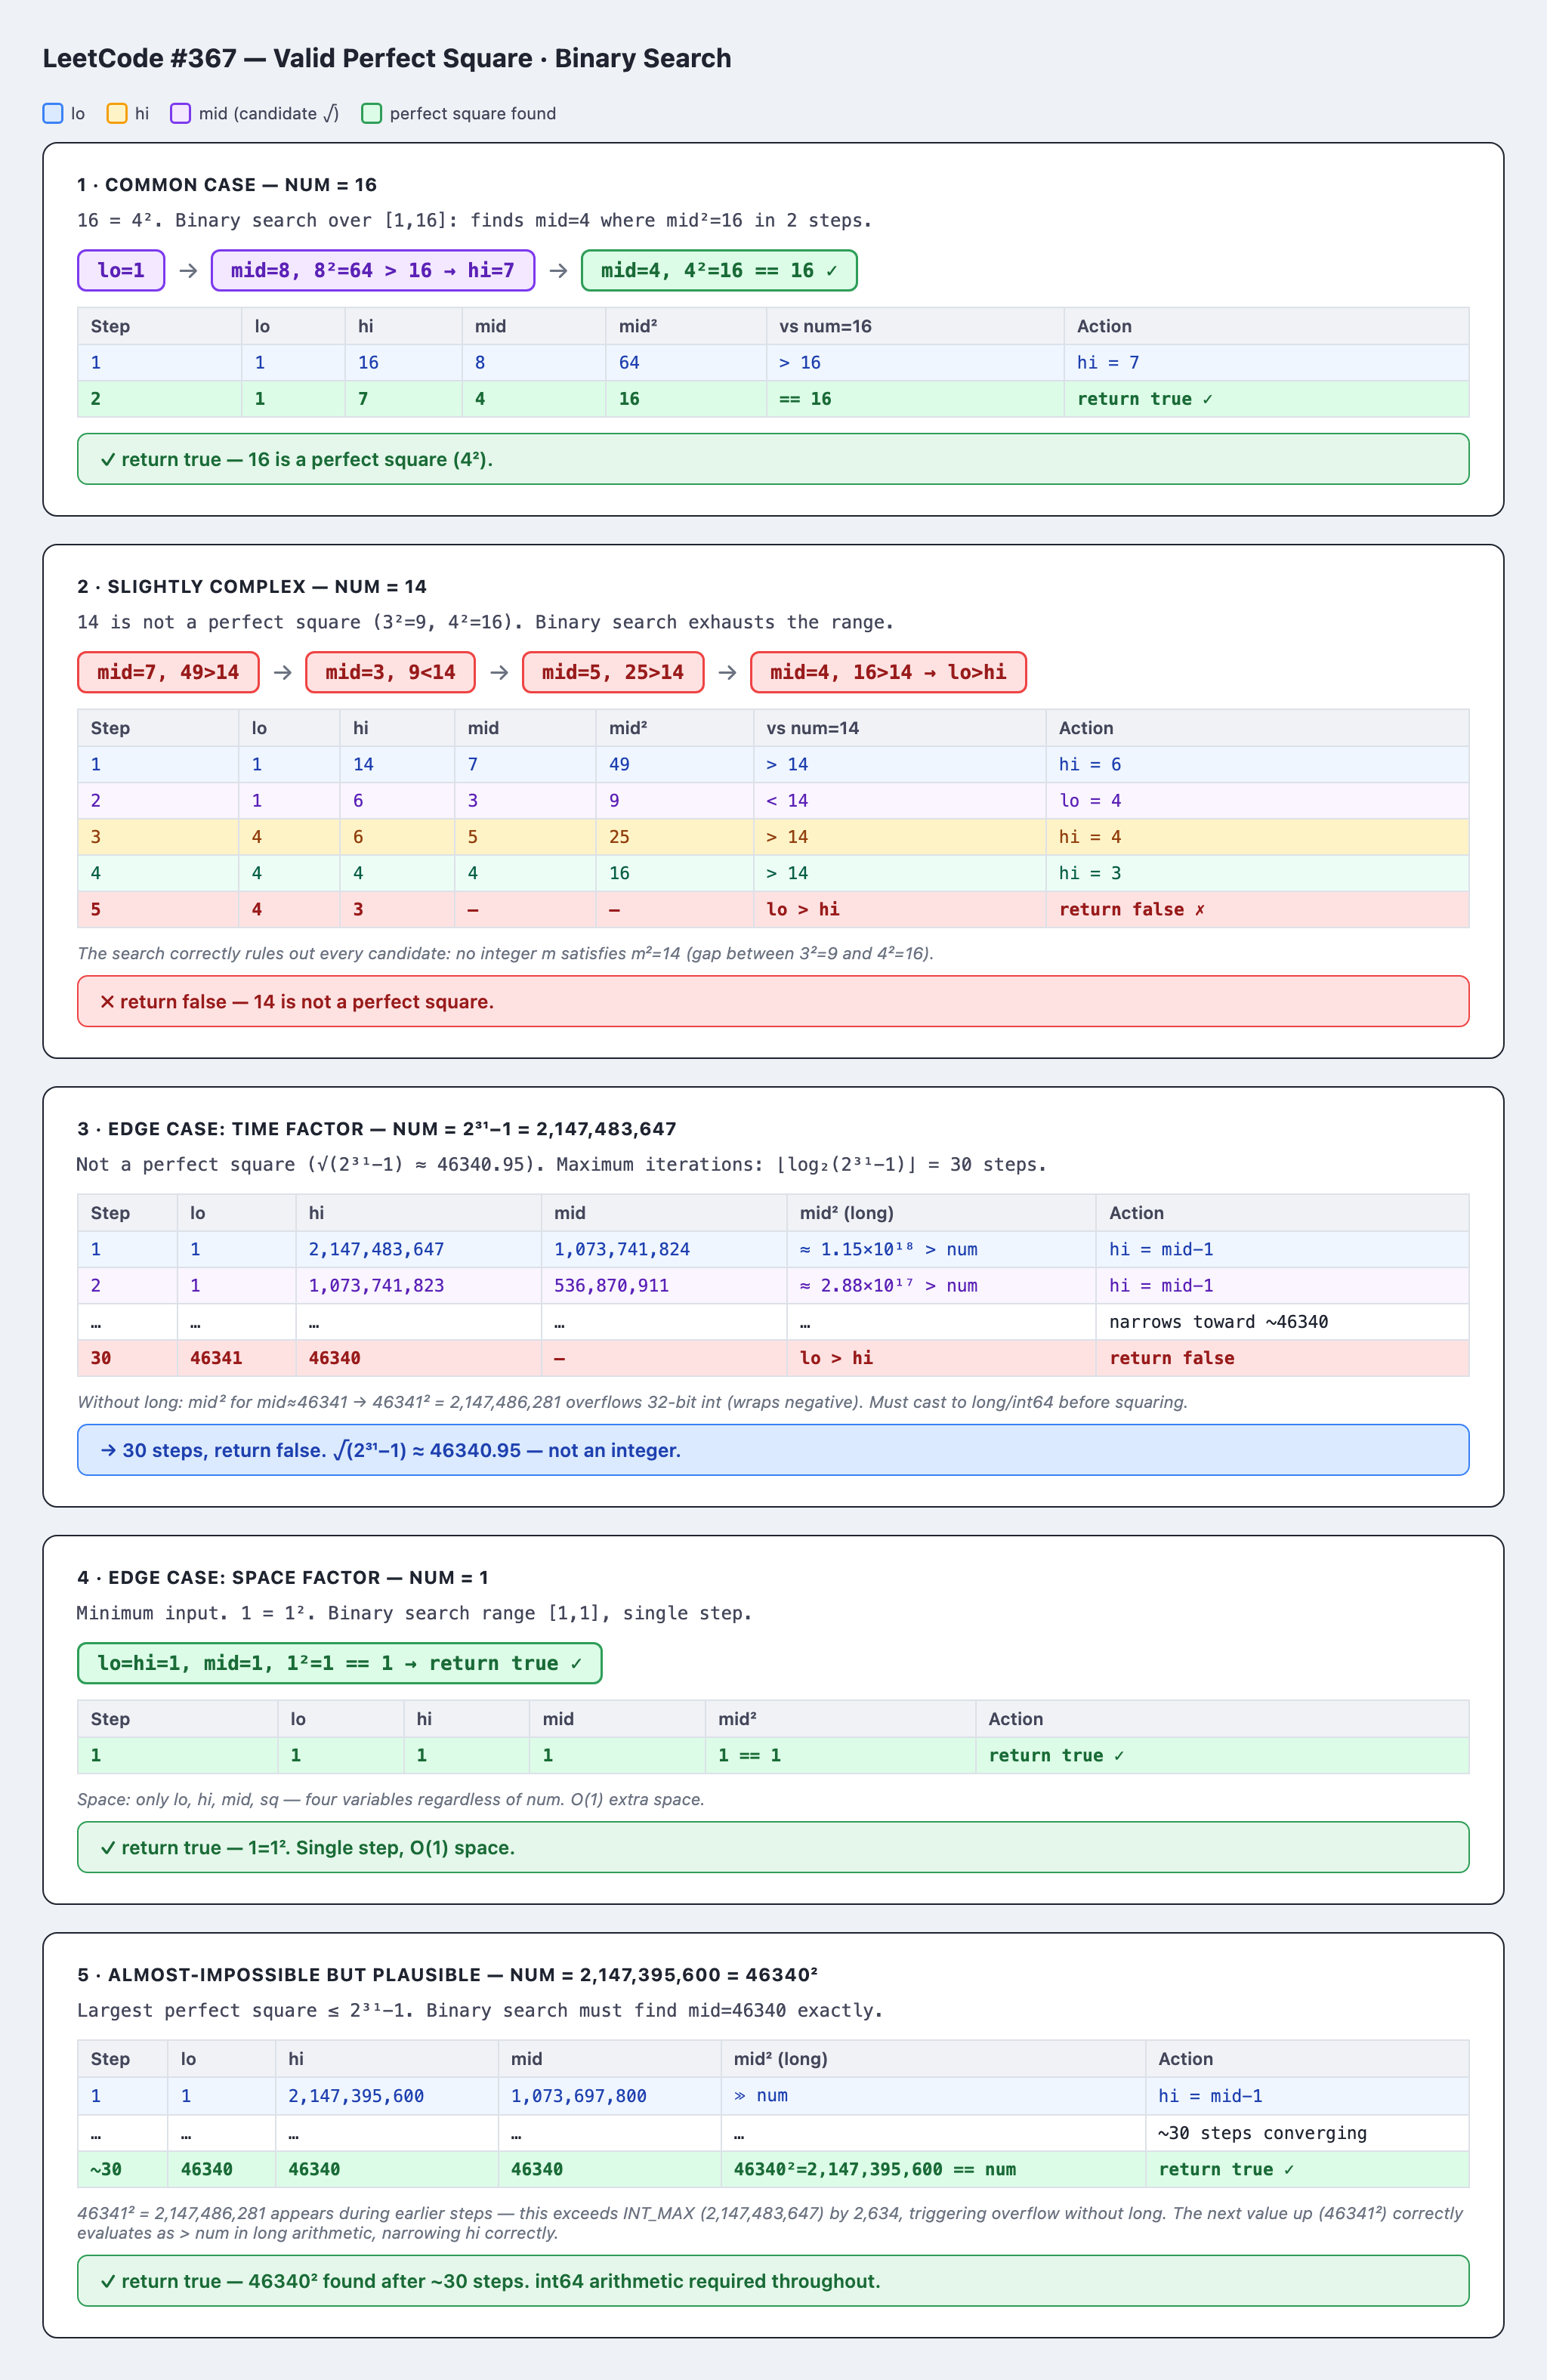